In [28]:
from src.feature_builder import big_table
df = big_table()
df.head()

,Driver,TeamName,Year,EventName,IsSprint,RecentQForm,driver_points_last_3,team_points_last_3,WeekendRainFlag,AvgPreQualiTemp,...,SessionRank_SQ,SessionRank_SS,TheoreticalDelta_FP1,TheoreticalDelta_FP2,TheoreticalDelta_FP3,TheoreticalDelta_Q,TheoreticalDelta_SQ,TheoreticalDelta_SS,Q_Rank_LastYear,Q_Delta_LastYear
0,ALB,Williams,2022,Abu Dhabi Grand Prix,0,14.000000,0.0,0.0,0,43.975238,...,NaN,NaN,1.151,1.617,1.027,2.204,NaN,NaN,NaN,NaN
1,ALB,Williams,2022,Australian Grand Prix,0,15.000000,0.0,0.0,0,32.075949,...,NaN,NaN,3.002,2.746,1.752,2.003,NaN,NaN,NaN,NaN
2,ALB,Williams,2022,Austrian Grand Prix,1,15.000000,0.0,0.0,0,38.452475,...,18.0,NaN,1.190,1.262,NaN,1.359,1.915,NaN,NaN,NaN
3,ALB,Williams,2022,Azerbaijan Grand Prix,0,17.666667,2.0,2.0,0,45.661702,...,NaN,NaN,3.011,3.462,2.418,3.287,NaN,NaN,NaN,NaN
4,ALB,Williams,2022,Belgian Grand Prix,0,15.333333,0.0,0.0,0,20.267187,...,NaN,NaN,0.922,2.013,1.760,1.614,NaN,NaN,NaN,NaN


In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. Kopiujemy dane z Feature Buildera
data = df.copy()

# 2. Usuwamy kolumny tekstowe lub zamieniamy je na liczby (Label Encoding)
le = LabelEncoder()
for col in ["Driver", "TeamName", "EventName"]:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 3. Definiujemy cel: przewidujemy pozycję w kwalifikacjach
target_col = "SessionRank_Q"

# ANTI-LEAKAGE SHIELD: Szukamy wszystkich kolumn kwalifikacyjnych oprócz targetu
q_columns = [
    col for col in data.columns if col.endswith("_Q") and col != target_col
]

# Wywalamy zbędne rzeczy i DOPISUJEMY TARGET, żeby wyleciał z macierzy cech X!
meta_columns = ["TeamSlug"]
columns_to_drop = q_columns + meta_columns + [target_col]

# Pozostawiamy do usunięcia tylko te, które faktycznie istnieją w tabeli
columns_to_drop = [c for c in columns_to_drop if c in data.columns]

X = data.drop(columns=columns_to_drop)
y = data[target_col]

# Usuwamy wiersze, w których target jest pusty
X = X[y.notna()]
y = y.dropna()

# 4. Chronologiczny podział danych (Szeregi czasowe)
train_mask = X["Year"] < 2025
test_mask = X["Year"] == 2025

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Usuwamy kolumnę 'Year' ze zbiorów cech
X_train = X_train.drop(columns=["Year"])
X_test = X_test.drop(columns=["Year"])

# 5. Budujemy i trenujemy model XGBoost
model = xgb.XGBRegressor(
    n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42
)
model_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=4,
    random_state=1,
)
model_rf.fit(X_train, y_train)
preds_rf = model_rf.predict(X_test)
print(
    "Uruchamiam armię drzew decyzyjnych... Trenuję czysty model bez ściągawek! 🏎️"
)
model.fit(X_train, y_train)
print("✅ Sukces! Model został pomyślnie wytrenowany!")

# 6. Sprawdzamy jak dobrze mu poszło na danych testowych
preds = model.predict(X_test)
print(True)  # Informacja dla systemu, że kod gotowy

Uruchamiam armię drzew decyzyjnych... Trenuję czysty model bez ściągawek! 🏎️
✅ Sukces! Model został pomyślnie wytrenowany!
True


📊 Średni błąd modelu (MAE): 2.92 miejsc
--------------------------------------------------
🏆 TOP 10 najważniejszych cech według XGBoosta:
               Cecha  Ważność
         RecentQForm 0.245116
driver_points_last_3 0.134112
  team_points_last_3 0.097211
     SessionRank_FP3 0.055210
     SessionRank_FP2 0.051701
      SessionRank_SQ 0.031357
TheoreticalDelta_FP1 0.026834
   DeltaToLeader_FP1 0.026085
   DeltaToLeader_FP2 0.025008
    Q_Delta_LastYear 0.024125


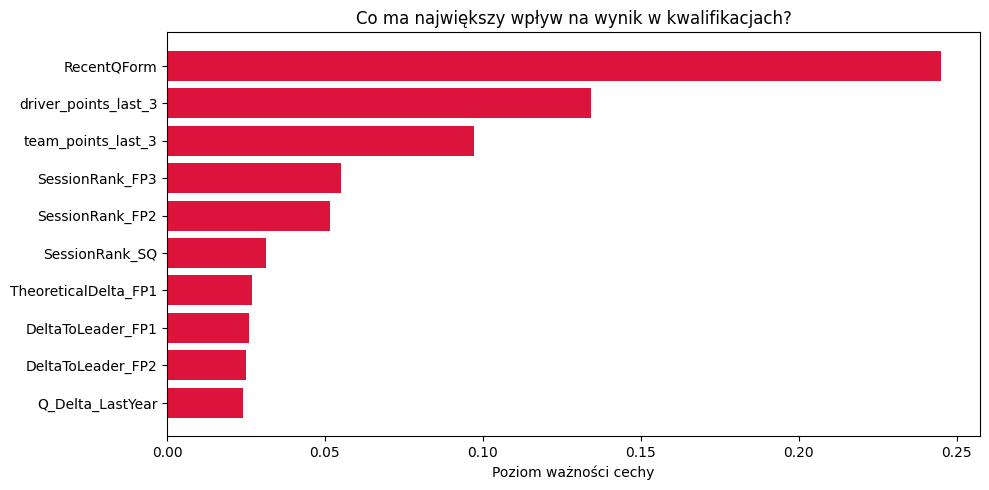

In [30]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obliczamy średni błąd modelu na danych testowych
mae = mean_absolute_error(y_test, preds)
print(f"📊 Średni błąd modelu (MAE): {mae:.2f} miejsc")
print("--------------------------------------------------")

# 2. Wyciągamy ważność cech (Feature Importance)
# POPRAWKA: Zmieniono X.columns na X_train.columns, żeby liczba cech się zgadzała
importance = pd.DataFrame({
    "Cecha": X_train.columns,
    "Ważność": model.feature_importances_,
}).sort_values(by="Ważność", ascending=False)

print("🏆 TOP 10 najważniejszych cech według XGBoosta:")
print(importance.head(10).to_string(index=False))

# 3. Rysujemy prosty wykres dla prowadzącego na zajęcia
plt.figure(figsize=(10, 5))
plt.barh(
    importance["Cecha"].head(10)[::-1],
    importance["Ważność"].head(10)[::-1],
    color="crimson",
)
plt.title("Co ma największy wpływ na wynik w kwalifikacjach?")
plt.xlabel("Poziom ważności cechy")
plt.tight_layout()
plt.show()